# PASegNet — Plane-Aware Segmentation Network

## Descripción General

Este notebook presenta la implementación, entrenamiento y evaluación de
**PASegNet** (*Plane-Aware Segmentation Network*), la arquitectura de
segmentación propuesta en este trabajo como contribución principal al
estado del arte en segmentación de tumores cerebrales sobre el dataset
BRISC 2025 (Fateh et al., *Scientific Data*, Nature Portfolio, 2026).

## Contexto y Motivación

Las fases previas del proyecto establecieron las bases para este trabajo:

- **Fase 3 — EDA:** El análisis exploratorio documentó hallazgos estadísticos
  no reportados por los autores originales del dataset, entre ellos que el
  rendimiento de segmentación difiere significativamente entre planos
  anatómicos (Sagittal > Coronal > Axial, χ²=42.76, p<0.0001), y que
  el desbalance tumor/fondo es extremo (~1.7% vs. ~98.3%).

- **Fase 4 — Preprocesamiento:** Se diseñó y verificó el pipeline de
  preprocesamiento, generando los splits estratificados de entrenamiento,
  validación y test.

- **Fase 5 — Benchmarks:** Se entrenaron 5 arquitecturas de referencia bajo
  condiciones experimentales estandarizadas. El mejor resultado obtenido fue
  UNet++ con **Weighted mIoU = 79.90%** y **Dice = 0.8674**, superando en
  2–8 puntos porcentuales los resultados reportados en el paper original
  de BRISC. El SOTA externo a superar es SaberNet con **80.6% mIoU**
  (Fateh et al., 2026).

## Contribución de este Notebook

PASegNet integra tres innovaciones arquitecturales motivadas empíricamente
por los hallazgos del EDA y los benchmarks:

1. **ASPP+** — Módulo de contexto multi-escala en el bottleneck, que aborda
   la dificultad de segmentación de gliomas irregulares y difusos.
2. **Attention Gates con FiLM** — Skip connections atendidas que suprimen
   el ruido de fondo dominante antes de la concatenación en el decoder.
3. **FiLM por plano anatómico** — Adaptación de features al plano de
   adquisición, motivada por el hallazgo original de rendimiento diferencial
   entre planos anatómicos.

## Meta Cuantitativa

| Métrica | Score a superar | Referencia |
|---|---|---|
| Weighted mIoU | > 80.6% | SaberNet — Fateh et al., 2026 |
| Global Dice | > 0.8674 | UNet++ — Este trabajo, Fase 5 |
| mIoU Glioma | > 75.2% | DAD — Fateh et al., 2026 |
| mIoU Meningioma | > 82.4% | SaberNet — Fateh et al., 2026 |
| mIoU Pituitary | > 84.7% | ABANet — Fateh et al., 2026 |


## Sección 1 — Configuración del Entorno

**Objetivo:** Importar las librerías necesarias y establecer la configuración
base del entorno de ejecución: semilla de reproducibilidad, dispositivo de
cómputo y verificación de versiones.

La configuración es idéntica a la utilizada en `benchmark2.ipynb` para
garantizar comparabilidad total de resultados. La semilla fija (42) aplicada
a PyTorch, CUDA y NumPy asegura reproducibilidad completa del experimento.


In [2]:
# ============================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ============================================================

import os
import time
import copy
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

# Procesamiento de imágenes
from PIL import Image

# Augmentación
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Segmentation Models PyTorch
import segmentation_models_pytorch as smp

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("  CONFIGURACIÓN DEL ENTORNO — PASegNet")
print("=" * 60)
print(f"  PyTorch : {torch.__version__}")
print(f"  Device  : {device}")
if torch.cuda.is_available():
    print(f"  GPU     : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"  Seed    : {SEED}")
print("=" * 60)


c:\Users\johan\miniconda3\envs\deep_learning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  CONFIGURACIÓN DEL ENTORNO — PASegNet
  PyTorch : 2.5.1+cu121
  Device  : cuda
  GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM    : 4.0 GB
  Seed    : 42


## Sección 2 — Carga de Datos y DataLoaders

**Objetivo:** Construir los DataLoaders de PyTorch que alimentarán el
entrenamiento de PASegNet, aplicando el pipeline de preprocesamiento
diseñado y verificado en la Fase 4 del proyecto (`preprocesamiento2.ipynb`).

### Pipeline de preprocesamiento aplicado

El pipeline transforma cada par imagen–máscara desde su formato original
en disco (JPEG, 512×512, RGB) hasta tensores PyTorch listos para el modelo:

| Paso | Operación | Justificación |
|---|---|---|
| 1 | Conversión a escala de grises (1 canal) | El dataset presenta modos de color mixtos (RGB y L); se unifica a 1 canal grayscale |
| 2 | Normalización a [0, 1] | La variabilidad de intensidad entre clases y planos justifica normalización por imagen individual |
| 3 | Resize a 256×256 px | Estandariza las 140 resoluciones distintas del dataset; compatible con la VRAM disponible |
| 4 | Binarización de máscara (umbral > 0.5) | Las máscaras contienen ~15 valores intermedios por antialiasing; se eliminan para obtener segmentación binaria estricta |
| 5 | Re-binarización post-transforms | Algunos transforms de Albumentations pueden reintroducir valores intermedios por interpolación; esta operación los elimina |
| 6 | Conversión a tensor float32 | Formato requerido por PyTorch para operaciones en GPU |

### Augmentación (exclusivamente en entrenamiento)

Las siguientes transformaciones se aplican de forma aleatoria y coherente
sobre la imagen y su máscara correspondiente:

| Augmentación | Parámetros | Justificación |
|---|---|---|
| HorizontalFlip | p=0.5 | La anatomía cerebral es aproximadamente simétrica; los tumores no tienen lateralidad preferente |
| VerticalFlip | p=0.3 | Incrementa variabilidad de orientación sin alterar la naturaleza de la imagen |
| RandomRotate90 | p=0.3 | Simula variaciones menores en el posicionamiento del paciente durante la adquisición |
| ShiftScaleRotate | shift±5%, scale±10%, rot±15°, p=0.4 | Combate el sesgo de localización espacial documentado en el EDA |
| ElasticTransform | alpha=50, sigma=10, p=0.2 | Simula deformaciones tisulares leves propias de la variabilidad anatómica interindividual |
| RandomBrightnessContrast | ±15%, p=0.4 | Compensa la variabilidad de intensidad entre clases y planos anatómicos |
| GaussNoise | var=(5, 25), p=0.3 | Simula el ruido inherente a las adquisiciones MRI |
| GaussianBlur | kernel (3,5), p=0.2 | Simula variaciones en la resolución efectiva entre escáneres |

Los conjuntos de validación y test no reciben augmentación, garantizando
una evaluación determinista y reproducible.

### Particiones utilizadas

Los splits fueron generados en `preprocesamiento2.ipynb` mediante
estratificación por la interacción tipo tumoral × plano anatómico:

| Partición | Imágenes | Batches | Augmentación |
|---|---|---|---|
| Train | 3,146 | 196 | Sí |
| Validation | 787 | 50 | No |
| Test | 860 | 54 | No |

### Integración con el módulo FiLM

El campo `plane_label` retornado por cada muestra (`'Axial'`, `'Coronal'`,
`'Sagittal'`) es convertido a índices enteros mediante
`PLANE_TO_IDX = {'Axial':0, 'Coronal':1, 'Sagittal':2}` y pasado
directamente al modelo en cada forward pass para condicionar el módulo
FiLM de adaptación por plano anatómico.


In [3]:
# ============================================================
# 2. CARGA DE DATOS — Consistente con preprocesamiento2.ipynb
# ============================================================

base_path    = r"C:\Users\johan\Downloads\Proyectos academicos\imagenes_tumores_cerebrales\brisc2025"
IMG_SIZE     = 256
BATCH_SIZE   = 16
NUM_WORKERS  = 0
PIN_MEMORY   = True

TUMOR_MAP    = {'gl': 'Glioma', 'me': 'Meningioma', 'pi': 'Pituitary'}
PLANE_MAP    = {'ax': 'Axial',  'co': 'Coronal',    'sa': 'Sagittal'}
PLANE_TO_IDX = {'Axial': 0, 'Coronal': 1, 'Sagittal': 2}

# ─── Cargar splits generados en preprocesamiento2.ipynb ───
df_train = pd.read_csv(os.path.join(base_path, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(base_path, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(base_path, 'split_test.csv'))

print(f"Splits cargados:")
print(f"   Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}")


# ─── Dataset class — idéntica a preprocesamiento2.ipynb ───
class BRISCSegDataset(Dataset):
    """
    Dataset de segmentación para BRISC 2025.
    Idéntico al definido en preprocesamiento2.ipynb para
    garantizar comparabilidad total con los benchmarks.

    Cada muestra retorna:
        image : tensor float32 (1, H, W), normalizado [0, 1]
        mask  : tensor float32 (1, H, W), binario {0, 1}
        meta  : diccionario con metadatos de la muestra
    """
    def __init__(self, dataframe, transforms=None):
        self.df         = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = np.array(
            Image.open(row['image_path']).convert('L'),
            dtype=np.float32
        ) / 255.0

        mask = np.array(
            Image.open(row['mask_path']).convert('L'),
            dtype=np.float32
        ) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask  = transformed['mask']
        else:
            image = torch.from_numpy(image)
            mask  = torch.from_numpy(mask)

        # Re-binarización de seguridad post-transforms
        mask = (mask > 0.5).float()

        if image.ndim == 2:
            image = image.unsqueeze(0)
        if mask.ndim == 2:
            mask  = mask.unsqueeze(0)

        meta = {
            'filename':    row['filename'],
            'tumor_label': row['tumor_label'],
            'plane_label': row['plane_label'],
            'tumor_code':  row['tumor_code'],
            'plane_code':  row['plane_code'],
        }
        return image, mask, meta

    def get_labels_for_stratification(self):
        return (self.df['tumor_label'] + '_' + self.df['plane_label']).values


# ─── Transforms — mismo estilo que preprocesamiento2.ipynb ───
def get_train_transforms(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size, interpolation=1, mask_interpolation=0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=15, border_mode=0, p=0.4),
        A.ElasticTransform(alpha=50, sigma=10, border_mode=0, p=0.2),
        A.RandomBrightnessContrast(brightness_limit=0.15,
                                   contrast_limit=0.15, p=0.4),
        A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        ToTensorV2(),
    ])


def get_val_test_transforms(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size, interpolation=1, mask_interpolation=0),
        ToTensorV2(),
    ])


# ─── Datasets y DataLoaders ───
train_dataset = BRISCSegDataset(df_train, transforms=get_train_transforms())
val_dataset   = BRISCSegDataset(df_val,   transforms=get_val_test_transforms())
test_dataset  = BRISCSegDataset(df_test,  transforms=get_val_test_transforms())

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)

print(f"\nDataLoaders:")
print(f"   Train : {len(train_loader)} batches ({len(train_dataset)} imágenes)")
print(f"   Val   : {len(val_loader)} batches ({len(val_dataset)} imágenes)")
print(f"   Test  : {len(test_loader)} batches ({len(test_dataset)} imágenes)")


Splits cargados:
   Train : 3146 | Val : 787 | Test : 860

DataLoaders:
   Train : 196 batches (3146 imágenes)
   Val   : 50 batches (787 imágenes)
   Test  : 54 batches (860 imágenes)


## Sección 3 — Funciones de Pérdida y Métricas

**Objetivo:** Definir la función de pérdida compuesta **PASegNetLoss** y las
métricas de evaluación que se usarán durante el entrenamiento y la evaluación
del modelo.

### PASegNetLoss

La función de pérdida combina tres términos:

$$\mathcal{L}_{total} = \lambda_1 \cdot \mathcal{L}_{Dice} +
\lambda_2 \cdot \mathcal{L}_{BCE} + \lambda_3 \cdot \mathcal{L}_{boundary}$$

con $\lambda_1 = 0.5$, $\lambda_2 = 0.3$, $\lambda_3 = 0.2$.

| Componente | Motivación |
|---|---|
| **Dice Loss** | Maneja el desbalance extremo documentado en el EDA: 1.7% de píxeles corresponden a tumor frente a un 98.3% de fondo. La Cross-Entropy estándar es inadecuada bajo este desbalance — un modelo que predice fondo en todos los píxeles alcanzaría >98% de accuracy |
| **BCE Loss** | Estabiliza el gradiente en la región dominante de fondo, complementando el Dice Loss |
| **Boundary Loss** | Las máscaras de BRISC presentan ~15 valores únicos por antialiasing en los bordes (EDA, hallazgo #9). Este término penaliza específicamente los errores en la región de borde, extraída mediante morfología (dilatación − erosión). Referencia: Kervadec et al., MIDL 2019 |

### Métricas de evaluación

Las funciones `compute_iou()` y `compute_dice()` son idénticas a las
utilizadas en `benchmark2.ipynb`, garantizando comparabilidad directa
de resultados entre PASegNet y los modelos de referencia.


In [13]:
# ============================================================
# 3. FUNCIONES DE PÉRDIDA Y MÉTRICAS
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred        = torch.sigmoid(pred)
        pred_flat   = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1.0 - dice


class BoundaryLoss(nn.Module):
    """
    Penaliza errores en la región de borde de la máscara ground truth.
    La región de borde se extrae mediante morfología: dilatación − erosión.

    Referencia: Kervadec et al., MIDL 2019.
    Motivación: máscaras BRISC con ~15 valores únicos por antialiasing.
    """
    def __init__(self, dilation_kernel_size=3):
        super().__init__()
        k = dilation_kernel_size
        self.register_buffer('kernel', torch.ones(1, 1, k, k))
        self.pad = k // 2
        self.bce = nn.BCEWithLogitsLoss()
        
    def _morphology(self, mask, op='dilate'):
        kernel = self.kernel.to(mask)
        
        x = F.conv2d(mask, kernel, padding=self.pad)
        
        if op == 'dilate':
            return (x > 0).float()
        else:
            return (x == kernel.sum()).float()

    def forward(self, pred, target):
        with torch.no_grad():
            dilated = self._morphology(target, 'dilate')
            eroded  = self._morphology(target, 'erode')
            border  = (dilated - eroded).clamp(0, 1)

        if border.sum() < 1:
            return torch.tensor(0.0, device=pred.device, requires_grad=True)

        return self.bce(pred * border, target * border)


class PASegNetLoss(nn.Module):
    """
    Función de pérdida compuesta para PASegNet:
    L = λ1·Dice + λ2·BCE + λ3·Boundary
    """
    def __init__(self, lambda1=0.5, lambda2=0.3, lambda3=0.2, smooth=1.0):
        super().__init__()
        self.lambda1       = lambda1
        self.lambda2       = lambda2
        self.lambda3       = lambda3
        self.dice_loss     = DiceLoss(smooth=smooth)
        self.bce_loss      = nn.BCEWithLogitsLoss()
        self.boundary_loss = BoundaryLoss(dilation_kernel_size=3)

    def forward(self, pred, target):
        return (self.lambda1 * self.dice_loss(pred, target) +
                self.lambda2 * self.bce_loss(pred, target)  +
                self.lambda3 * self.boundary_loss(pred, target))


class ComboLoss(nn.Module):
    """
    Función de pérdida estándar usada en los benchmarks.
    Se reutiliza aquí para los experimentos de ablation
    que no incluyen el término de borde (E0, E1, E2, E3).
    """
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha     = alpha
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_loss  = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return (self.alpha * self.dice_loss(pred, target) +
                (1 - self.alpha) * self.bce_loss(pred, target))


def compute_iou(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin     = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    union        = (pred_bin.sum(dim=(1, 2, 3)) +
                    target.sum(dim=(1, 2, 3)) - intersection)
    return (intersection + smooth) / (union + smooth)


def compute_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin     = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    return (2. * intersection + smooth) / (
        pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + smooth
    )


print("Funciones de pérdida definidas:")
print("   PASegNetLoss : λ1=0.5·Dice + λ2=0.3·BCE + λ3=0.2·Boundary")
print("   ComboLoss    : 0.5·Dice + 0.5·BCE  (ablation E0–E3)")
print("   Métricas     : IoU, Dice Score")


Funciones de pérdida definidas:
   PASegNetLoss : λ1=0.5·Dice + λ2=0.3·BCE + λ3=0.2·Boundary
   ComboLoss    : 0.5·Dice + 0.5·BCE  (ablation E0–E3)
   Métricas     : IoU, Dice Score


## Sección 4 — Arquitectura PASegNet

**Objetivo:** Implementar la arquitectura completa de PASegNet y sus
variantes para el ablation study. Cada módulo está motivado por un
hallazgo empírico concreto del análisis del dataset BRISC 2025.

### Principio de diseño — Data-Driven Architecture

Cada componente de PASegNet responde a una limitación identificada
empíricamente durante el EDA y los benchmarks:

| Módulo | Hallazgo que lo motiva | Referencia |
|---|---|---|
| **Encoder ResNet34** | Domina el rendimiento en los 5 benchmarks — el cuello de botella está en el decoder | Fase 5, este trabajo |
| **ASPP+** | DeepLabV3+ fue el modelo más débil (78.31% mIoU); Glioma tiene el Dice más bajo (~76%) por morfología difusa | Chen et al., 2018 + EDA |
| **Channel Attention** | Mejora la selección de escalas relevantes en la fusión multi-escala | Hu et al. (SE-Net), 2018 |
| **Attention Gates** | Sparsity del 1.7% — el 98.3% de fondo genera ruido masivo en las skip connections clásicas | Oktay et al., 2018 + EDA |
| **FiLM por plano** | Patrón Sagittal > Coronal > Axial consistente en los 5 modelos (p<0.0001) — hallazgo original de este trabajo | Perez et al., NeurIPS 2018 |
| **Boundary Loss** | Máscaras con ~15 valores únicos por antialiasing — errores sistemáticos en bordes | Kervadec et al., MIDL 2019 + EDA |

### Diagrama de la arquitectura completa



```mermaid
graph TD
    %% Estilos de color
    classDef input fill:#f5f5f5,stroke:#333,stroke-width:2px;
    classDef encoder fill:#e1f5fe,stroke:#01579b;
    classDef bottleneck fill:#fff9c4,stroke:#fbc02d;
    classDef film fill:#fce4ec,stroke:#c2185b,stroke-width:2px;
    classDef decoder fill:#e8f5e9,stroke:#2e7d32;

    %% Nodos principales
    IN([INPUT: 256×256×1]):::input
    
    subgraph Encoder [ENCODER: ResNet34 ImageNet]
        s1[s1: B, 64, 128, 128]
        s2[s2: B, 64, 64, 64]
        s3[s3: B, 128, 32, 32]
        s4[s4: B, 256, 16, 16]
        base[b: B, 512, 8, 8]
    end

    subgraph ASPP_Block [ASPP+ Multi-Scale Bottleneck]
        ASPP[r = {1, 6, 12, 18} + GAP<br/>+ Channel Attention Fusion]
        dim_aspp[→ B, 256, 8, 8]
    end

    FiLM{FiLM Layer: γ_p ⊙ F + β_p}:::film

    subgraph Decoder_Block [DECODER: 4 etapas]
        D4[D4: Upsample + AttGate s4 + Conv]
        D3[D3: Upsample + AttGate s3 + Conv]
        D2[D2: Upsample + AttGate s2 + Conv]
        D1[D1: Upsample + AttGate s1 + Conv]
    end

    OUT([OUTPUT: 256×256×1]):::input

    %% Conexiones de flujo
    IN --> s1 --> s2 --> s3 --> s4 --> base
    base --> ASPP
    ASPP --> dim_aspp
    dim_aspp --> FiLM
    FiLM --> D4 --> D3 --> D2 --> D1
    D1 --> OUT

    %% Conexiones Skip con Attention Gates (Punteadas)
    s4 -.-> D4
    s3 -.-> D3
    s2 -.-> D2
    s1 -.-> D1
```

In [5]:
# ============================================================
# 4. ARQUITECTURA PASegNet
# ============================================================


# ── Channel Attention (Squeeze-and-Excitation) ────────────
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


# ── ASPP+ ─────────────────────────────────────────────────
class ASPPPlus(nn.Module):
    """
    Atrous Spatial Pyramid Pooling mejorado con Channel Attention.
    Tasas de dilatación r={1,6,12,18} + Global Average Pooling.
    """
    def __init__(self, in_channels=512, out_channels=256):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3,
                      padding=6, dilation=6, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3,
                      padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.branch4 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3,
                      padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.branch5 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.channel_attn = ChannelAttention(out_channels, reduction=16)
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        b5 = F.interpolate(self.branch5(x), size=(h, w),
                           mode='bilinear', align_corners=False)
        out = torch.cat([self.branch1(x), self.branch2(x),
                         self.branch3(x), self.branch4(x), b5], dim=1)
        out = self.project(out)
        out = self.channel_attn(out)
        return self.dropout(out)


# ── FiLM Module ───────────────────────────────────────────
class FiLMModule(nn.Module):
    """
    Feature-wise Linear Modulation por plano anatómico.
    FiLM(F, p) = γ_p ⊙ F + β_p
    Planos: Axial=0, Coronal=1, Sagittal=2.
    """
    def __init__(self, num_features, num_planes=3):
        super().__init__()
        self.gamma = nn.Embedding(num_planes, num_features)
        self.beta  = nn.Embedding(num_planes, num_features)
        nn.init.ones_(self.gamma.weight)
        nn.init.zeros_(self.beta.weight)

    def forward(self, x, plane_idx):
        gamma = self.gamma(plane_idx).unsqueeze(-1).unsqueeze(-1)
        beta  = self.beta(plane_idx).unsqueeze(-1).unsqueeze(-1)
        return gamma * x + beta


# ── Plane-Aware Attention Gate ────────────────────────────
class PlaneAwareAttentionGate(nn.Module):
    """
    Attention Gate con señal de gating modulada por FiLM.
    α = σ(W_α · ReLU(W_g·FiLM(g,p) + W_x·x + b))
    x̂ = α ⊙ x
    """
    def __init__(self, F_g, F_x, F_int, num_planes=3):
        super().__init__()
        self.film = FiLMModule(F_g, num_planes)
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(
            nn.Conv2d(F_x, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x, plane_idx):
        g_film = self.film(g, plane_idx)
        g_up   = F.interpolate(g_film, size=x.shape[2:],
                               mode='bilinear', align_corners=False)
        alpha  = self.psi(self.relu(self.W_g(g_up) + self.W_x(x)))
        return x * alpha, alpha


# ── Decoder Block ─────────────────────────────────────────
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels,
                      3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels,
                      3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:],
                          mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


# ── PASegNet — Modelo Completo ────────────────────────────
class PASegNet(nn.Module):
    """
    Plane-Aware Segmentation Network.

    Args:
        use_aspp    : activa ASPP+ en el bottleneck
        use_attgates: activa Attention Gates en skip connections
        use_film    : activa FiLM de adaptación por plano
    """
    def __init__(self, encoder_name='resnet34', encoder_weights='imagenet',
                 in_channels=1, num_planes=3,
                 use_aspp=True, use_attgates=True, use_film=True):
        super().__init__()
        self.use_aspp     = use_aspp
        self.use_attgates = use_attgates
        self.use_film     = use_film

        # Encoder vía SMP
        _base = smp.Unet(encoder_name=encoder_name,
                         encoder_weights=encoder_weights,
                         in_channels=in_channels,
                         classes=1, activation=None)
        self.encoder = _base.encoder
        enc_ch = self.encoder.out_channels
        e1, e2, e3, e4, e5 = enc_ch[1], enc_ch[2], enc_ch[3], enc_ch[4], enc_ch[5]
        btn_ch = 256 if use_aspp else e5

        # Bottleneck
        if use_aspp:
            self.bottleneck = ASPPPlus(in_channels=e5, out_channels=256)

        # FiLM
        if use_film:
            self.film_bottleneck = FiLMModule(btn_ch, num_planes)

        # Attention Gates
        if use_attgates:
            self.ag4 = PlaneAwareAttentionGate(btn_ch, e4, btn_ch // 2)
            self.ag3 = PlaneAwareAttentionGate(128,    e3, 64)
            self.ag2 = PlaneAwareAttentionGate(64,     e2, 32)
            self.ag1 = PlaneAwareAttentionGate(32,     e1, 16)

        # Decoder
        self.dec4 = DecoderBlock(btn_ch, e4, 128)
        self.dec3 = DecoderBlock(128,    e3,  64)
        self.dec2 = DecoderBlock(64,     e2,  32)
        self.dec1 = DecoderBlock(32,     e1,  16)

        self.head          = nn.Conv2d(16, 1, kernel_size=1)
        self.attention_maps = {}

    def forward(self, x, plane_idx=None):
        features = self.encoder(x)
        s1, s2, s3, s4 = features[1], features[2], features[3], features[4]
        b = features[5]

        if self.use_aspp:
            b = self.bottleneck(b)

        if self.use_film and plane_idx is not None:
            b = self.film_bottleneck(b, plane_idx)

        if self.use_attgates and plane_idx is not None:
            s4, a4 = self.ag4(b,   s4, plane_idx)
            d4     = self.dec4(b,   s4)
            s3, a3 = self.ag3(d4,  s3, plane_idx)
            d3     = self.dec3(d4,  s3)
            s2, a2 = self.ag2(d3,  s2, plane_idx)
            d2     = self.dec2(d3,  s2)
            s1, a1 = self.ag1(d2,  s1, plane_idx)
            d1     = self.dec1(d2,  s1)
            self.attention_maps = {'a1': a1, 'a2': a2, 'a3': a3, 'a4': a4}
        else:
            d4 = self.dec4(b,  s4)
            d3 = self.dec3(d4, s3)
            d2 = self.dec2(d3, s2)
            d1 = self.dec1(d2, s1)

        out = F.interpolate(d1, size=x.shape[2:],
                            mode='bilinear', align_corners=False)
        return self.head(out)


# ── Funciones constructoras por experimento ───────────────
def build_pasegnet_e0():
    """E0 — Baseline: solo encoder + decoder, sin módulos innovadores."""
    return PASegNet(use_aspp=False, use_attgates=False, use_film=False)

def build_pasegnet_e1():
    """E1 — Baseline + ASPP+."""
    return PASegNet(use_aspp=True, use_attgates=False, use_film=False)

def build_pasegnet_e2():
    """E2 — Baseline + Attention Gates."""
    return PASegNet(use_aspp=False, use_attgates=True, use_film=True)

def build_pasegnet_e3():
    """E3 — Baseline + FiLM."""
    return PASegNet(use_aspp=False, use_attgates=False, use_film=True)

def build_pasegnet_e4():
    """E4 — Baseline + BoundaryLoss (misma arquitectura que E0)."""
    return PASegNet(use_aspp=False, use_attgates=False, use_film=False)

def build_pasegnet():
    """E5 — PASegNet completo: ASPP+ + AttGates + FiLM."""
    return PASegNet(use_aspp=True, use_attgates=True, use_film=True)


# ── Verificación de forward pass ──────────────────────────
print("Verificando PASegNet completo...")
_m    = build_pasegnet().to(device)
_x    = torch.randn(2, 1, 256, 256).to(device)
_pidx = torch.tensor([0, 2]).to(device)

total_p     = sum(p.numel() for p in _m.parameters())
trainable_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"  Parámetros totales     : {total_p:>12,}")
print(f"  Parámetros entrenables : {trainable_p:>12,}")
print(f"  Tamaño aprox.          : {total_p*4/1024**2:>8.1f} MB")

with torch.no_grad():
    _out = _m(_x, _pidx)
    assert _out.shape == (2, 1, 256, 256), "ERROR: forma incorrecta"
    print(f"  Input  : {list(_x.shape)}")
    print(f"  Output : {list(_out.shape)}")
    print("  Forward pass correcto")

del _m, _x, _pidx, _out
torch.cuda.empty_cache()


Verificando PASegNet completo...
  Parámetros totales     :   26,496,397
  Parámetros entrenables :   26,496,397
  Tamaño aprox.          :    101.1 MB
  Input  : [2, 1, 256, 256]
  Output : [2, 1, 256, 256]
  Forward pass correcto


## Sección 5 — Motor de Entrenamiento

**Objetivo:** Definir las funciones de entrenamiento y evaluación
adaptadas para PASegNet. Respecto al motor utilizado en
`benchmark2.ipynb`, los cambios son mínimos y específicos:

| Elemento | benchmark2.ipynb | modelo_propuesto.ipynb |
|---|---|---|
| Forward pass | `model(images)` | `model(images, plane_idx)` |
| Meta en el loop | Descartado (`_`) | Usado para extraer `plane_idx` |
| Función de pérdida | `ComboLoss` | `PASegNetLoss` o `ComboLoss` según experimento |

El sistema de guardado es idéntico al del benchmark: checkpoint `.pth`,
historial `.json` y resultados de test `.csv` se persisten a disco
inmediatamente al finalizar cada experimento.


In [6]:
# ============================================================
# 5. MOTOR DE ENTRENAMIENTO — Adaptado para PASegNet
# ============================================================

HPARAMS = {
    'max_epochs':         100,
    'patience':            15,
    'learning_rate':      1e-4,
    'weight_decay':       1e-4,
    'scheduler_patience':  5,
    'scheduler_factor':   0.5,
    'min_lr':             1e-7,
}


def get_plane_idx(meta, device):
    """Convierte strings de plano a tensor de índices enteros."""
    return torch.tensor(
        [PLANE_TO_IDX[p] for p in meta['plane_label']],
        dtype=torch.long, device=device
    )


def train_one_epoch_pasegnet(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = running_iou = running_dice = 0.0
    n_batches = 0

    for images, masks, meta in loader:
        images    = images.to(device)
        masks     = masks.to(device)
        plane_idx = get_plane_idx(meta, device)

        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = model(images, plane_idx)
            loss    = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            running_loss += loss.item()
            running_iou  += compute_iou(outputs, masks).mean().item()
            running_dice += compute_dice(outputs, masks).mean().item()
            n_batches    += 1

    return {'loss': running_loss/n_batches,
            'iou':  running_iou/n_batches,
            'dice': running_dice/n_batches}


@torch.no_grad()
def evaluate_pasegnet(model, loader, criterion, device):
    model.eval()
    running_loss = running_iou = running_dice = 0.0
    n_batches = 0

    for images, masks, meta in loader:
        images    = images.to(device)
        masks     = masks.to(device)
        plane_idx = get_plane_idx(meta, device)

        with autocast(device_type='cuda'):
            outputs = model(images, plane_idx)
            loss    = criterion(outputs, masks)

        running_loss += loss.item()
        running_iou  += compute_iou(outputs, masks).mean().item()
        running_dice += compute_dice(outputs, masks).mean().item()
        n_batches    += 1

    return {'loss': running_loss/n_batches,
            'iou':  running_iou/n_batches,
            'dice': running_dice/n_batches}


def train_pasegnet(model, model_name, train_loader, val_loader,
                   device, hparams=HPARAMS, use_boundary_loss=False):
    print(f"\n{'='*65}")
    print(f"  ENTRENAMIENTO: {model_name}")
    print(f"{'='*65}")

    total_p     = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parámetros totales     : {total_p:>12,}")
    print(f"  Parámetros entrenables : {trainable_p:>12,}")
    print(f"  Tamaño del modelo      : {total_p*4/1024**2:>10.1f} MB")

    model     = model.to(device)
    criterion = (PASegNetLoss(lambda1=0.5, lambda2=0.3, lambda3=0.2)
                 if use_boundary_loss else ComboLoss(alpha=0.5))
    optimizer = optim.AdamW(model.parameters(),
                            lr=hparams['learning_rate'],
                            weight_decay=hparams['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max',
        factor=hparams['scheduler_factor'],
        patience=hparams['scheduler_patience'],
        min_lr=hparams['min_lr'], verbose=False)
    scaler = GradScaler('cuda')

    history = {'train_loss':[], 'train_iou':[], 'train_dice':[],
               'val_loss':[],   'val_iou':[],   'val_dice':[], 'lr':[]}

    best_val_dice    = 0.0
    best_model_state = None
    patience_counter = 0
    best_epoch       = 0

    ckpt_dir    = os.path.join(base_path, 'checkpoints')
    results_dir = os.path.join(base_path, 'results')
    os.makedirs(ckpt_dir,    exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    start_time = time.time()

    for epoch in range(1, hparams['max_epochs'] + 1):
        epoch_start = time.time()
        train_m = train_one_epoch_pasegnet(
            model, train_loader, criterion, optimizer, scaler, device)
        val_m   = evaluate_pasegnet(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_m['dice'])

        for k in ['loss','iou','dice']:
            history[f'train_{k}'].append(train_m[k])
            history[f'val_{k}'].append(val_m[k])
        history['lr'].append(current_lr)

        improved = val_m['dice'] > best_val_dice
        if improved:
            best_val_dice    = val_m['dice']
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch       = epoch
            patience_counter = 0
            marker           = ' ★ BEST'
            torch.save({'epoch': epoch,
                        'model_state_dict': best_model_state,
                        'val_dice': best_val_dice,
                        'val_iou':  val_m['iou']},
                       os.path.join(ckpt_dir, f'{model_name}_best.pth'))
        else:
            patience_counter += 1
            marker = f' (patience: {patience_counter}/{hparams["patience"]})'

        print(f"  Epoch {epoch:3d}/{hparams['max_epochs']} │ "
              f"Train Loss:{train_m['loss']:.4f} "
              f"IoU:{train_m['iou']:.4f} "
              f"Dice:{train_m['dice']:.4f} │ "
              f"Val Loss:{val_m['loss']:.4f} "
              f"IoU:{val_m['iou']:.4f} "
              f"Dice:{val_m['dice']:.4f} │ "
              f"LR:{current_lr:.1e} │ "
              f"{time.time()-epoch_start:.1f}s{marker}")

        if patience_counter >= hparams['patience']:
            print(f"\n  Early Stopping epoch {epoch}. "
                  f"Mejor epoch: {best_epoch} (Val Dice: {best_val_dice:.4f})")
            break

    model.load_state_dict(best_model_state)

    safe_name = model_name.lower().replace(' ','_').replace('-','')
    with open(os.path.join(results_dir, f'{safe_name}_history.json'), 'w') as f:
        json.dump(history, f, indent=2)

    print(f"\n  Resumen — {model_name}")
    print(f"  Mejor epoch    : {best_epoch}")
    print(f"  Mejor Val Dice : {best_val_dice:.4f}")
    print(f"  Tiempo total   : {(time.time()-start_time)/60:.1f} min")

    return model, history


print("Motor de entrenamiento PASegNet definido.")


Motor de entrenamiento PASegNet definido.


## Sección 6 — Evaluación Detallada

**Objetivo:** Calcular métricas desagregadas por tipo tumoral y plano
anatómico sobre el conjunto de test. Este nivel de análisis constituye
una de las contribuciones originales del trabajo — ninguno de los
trabajos citantes de BRISC 2025 reporta métricas estratificadas
por plano anatómico.

### Métricas calculadas

| Métrica | Descripción |
|---|---|
| **Weighted mIoU** | mIoU ponderado por número de muestras por clase — métrica principal de comparación con el SOTA |
| **Global Dice** | Dice promedio sobre el test set completo |
| **mIoU por tumor** | Glioma / Meningioma / Pituitary |
| **mIoU por plano** | Axial / Coronal / Sagittal — evalúa el impacto del módulo FiLM |
| **Tabla Tumor × Plano** | Matriz 3×3 de mIoU cruzados |


In [7]:
# ============================================================
# 6. EVALUACIÓN DETALLADA Y GUARDADO DE RESULTADOS
# ============================================================

@torch.no_grad()
def evaluate_detailed_pasegnet(model, loader, device, model_name="PASegNet"):
    model.eval()
    all_results = []

    for images, masks, meta in loader:
        images    = images.to(device)
        masks     = masks.to(device)
        plane_idx = get_plane_idx(meta, device)

        with autocast(device_type='cuda'):
            outputs = model(images, plane_idx)

        ious  = compute_iou(outputs, masks)
        dices = compute_dice(outputs, masks)

        for i in range(len(images)):
            all_results.append({
                'filename':    meta['filename'][i],
                'tumor_label': meta['tumor_label'][i],
                'plane_label': meta['plane_label'][i],
                'iou':         ious[i].item(),
                'dice':        dices[i].item(),
            })

    results_df    = pd.DataFrame(all_results)
    tumor_iou     = results_df.groupby('tumor_label')['iou'].mean()
    tumor_counts  = results_df.groupby('tumor_label')['iou'].count()
    weighted_miou = (tumor_iou * tumor_counts / tumor_counts.sum()).sum()
    plane_iou     = results_df.groupby('plane_label')['iou'].mean()
    global_dice   = results_df['dice'].mean()
    global_iou    = results_df['iou'].mean()

    summary = {
        'model_name':    model_name,
        'global_iou':    global_iou,
        'global_dice':   global_dice,
        'weighted_miou': weighted_miou,
        'tumor_iou':     tumor_iou.to_dict(),
        'plane_iou':     plane_iou.to_dict(),
        'tumor_dice':    results_df.groupby('tumor_label')['dice'].mean().to_dict(),
        'plane_dice':    results_df.groupby('plane_label')['dice'].mean().to_dict(),
        'cross_iou':     results_df.groupby(
            ['tumor_label','plane_label'])['iou'].mean().to_dict(),
    }

    print(f"\n{'='*65}")
    print(f"  RESULTADOS EN TEST — {model_name}")
    print(f"{'='*65}")
    print(f"  Weighted mIoU : {weighted_miou*100:.2f}%")
    print(f"  Global mIoU   : {global_iou*100:.2f}%")
    print(f"  Global Dice   : {global_dice*100:.2f}%")
    print(f"\n  mIoU por Tipo Tumoral:")
    for t in ['Glioma','Meningioma','Pituitary']:
        print(f"    {t:<15} {tumor_iou.get(t,0)*100:.2f}%")
    print(f"\n  mIoU por Plano Anatómico:")
    for p in ['Axial','Coronal','Sagittal']:
        print(f"    {p:<15} {plane_iou.get(p,0)*100:.2f}%")
    print(f"\n  Tabla Tumor × Plano:")
    cross = results_df.pivot_table(
        values='iou', index='tumor_label',
        columns='plane_label', aggfunc='mean'
    ).reindex(index=['Glioma','Meningioma','Pituitary'],
              columns=['Axial','Coronal','Sagittal']) * 100
    print(cross.round(2).to_string())

    return results_df, summary


def save_pasegnet_results(model_name, model, history,
                          test_loader, device, base_path):
    results_dir = os.path.join(base_path, 'results')
    os.makedirs(results_dir, exist_ok=True)
    safe_name = model_name.lower().replace(' ','_').replace('-','')

    results_df, summary = evaluate_detailed_pasegnet(
        model, test_loader, device, model_name)

    results_df.to_csv(
        os.path.join(results_dir, f'{safe_name}_test_results.csv'), index=False)

    summary_s = {k: ({str(kk): vv for kk,vv in v.items()}
                     if isinstance(v, dict) else v)
                 for k, v in summary.items()}
    with open(os.path.join(results_dir, f'{safe_name}_summary.json'), 'w') as f:
        json.dump(summary_s, f, indent=2)

    print(f"\n  Resultados guardados en {results_dir}/")
    return results_df, summary


def plot_training_curves_pasegnet(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    for ax, (tr, vl), title in zip(
        axes,
        [('train_loss','val_loss'),
         ('train_iou', 'val_iou'),
         ('train_dice','val_dice')],
        ['Loss', 'IoU', 'Dice Score']
    ):
        ax.plot(epochs, history[tr], 'b-', label='Train',      lw=1.5)
        ax.plot(epochs, history[vl], 'r-', label='Validation', lw=1.5)
        ax.set_title(f'{model_name} — {title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle(f'Curvas de Entrenamiento — {model_name}',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()


print("Funciones de evaluación y visualización definidas.")


Funciones de evaluación y visualización definidas.


## Sección 7 — Ablation Study y Entrenamiento del Modelo Completo

**Objetivo:** Entrenar y evaluar cada variante de PASegNet de forma
independiente para cuantificar la contribución individual de cada
módulo innovador. Este ablation study es un requisito metodológico
estándar en publicaciones de segmentación médica — permite demostrar
que cada componente añade valor real y que la mejora no se debe
únicamente a la combinación en bloque.

### Diseño del ablation study

Cada experimento activa un único módulo nuevo sobre la misma arquitectura
base (Encoder ResNet34 + Decoder U-Net estándar), manteniendo todos los
demás hiperparámetros constantes:

| Experimento | Módulos activos | Loss | Propósito |
|---|---|---|---|
| **E0 — Baseline** | Ninguno | ComboLoss | Punto de partida controlado |
| **E1 — +ASPP+** | ASPP+ | ComboLoss | Aislar contribución del contexto multi-escala |
| **E2 — +AttGates** | Attention Gates + FiLM* | ComboLoss | Aislar contribución de la supresión de ruido |
| **E3 — +FiLM** | FiLM | ComboLoss | Aislar contribución de la adaptación por plano |
| **E4 — +BoundaryLoss** | Ninguno | PASegNetLoss | Aislar contribución del término de borde |
| **E5 — Full PASegNet** | ASPP+ + AttGates + FiLM | PASegNetLoss | Modelo propuesto completo |

*Los Attention Gates requieren FiLM para recibir la señal de plano.

### Sistema de reanudación automática

Cada celda verifica si el experimento ya fue completado consultando la
existencia del checkpoint `.pth`, el historial `.json` y el summary `.json`.
Si todos existen, carga los resultados desde disco sin reentrenar,
permitiendo reiniciar el notebook sin perder progreso.


### Experimento E0 — Baseline

Arquitectura de referencia interna: encoder ResNet34 preentrenado en
ImageNet conectado directamente a un decoder U-Net estándar, sin ninguno
de los módulos innovadores de PASegNet. Este experimento establece el
punto de partida para cuantificar el aporte incremental de cada módulo.
La función de pérdida es ComboLoss (0.5·Dice + 0.5·BCE), idéntica
a la utilizada en los benchmarks de la Fase 5.


  Iniciando entrenamiento: PASegNet_E0_Baseline...

  ENTRENAMIENTO: PASegNet_E0_Baseline
  Parámetros totales     :   22,558,097
  Parámetros entrenables :   22,558,097
  Tamaño del modelo      :       86.1 MB
  Epoch   1/100 │ Train Loss:0.6603 IoU:0.3237 Dice:0.4299 │ Val Loss:0.6227 IoU:0.5193 Dice:0.6402 │ LR:1.0e-04 │ 73.5s ★ BEST
  Epoch   2/100 │ Train Loss:0.6086 IoU:0.4861 Dice:0.6053 │ Val Loss:0.5936 IoU:0.5393 Dice:0.6658 │ LR:1.0e-04 │ 65.6s ★ BEST
  Epoch   3/100 │ Train Loss:0.5813 IoU:0.5361 Dice:0.6541 │ Val Loss:0.5650 IoU:0.5786 Dice:0.7049 │ LR:1.0e-04 │ 64.8s ★ BEST
  Epoch   4/100 │ Train Loss:0.5550 IoU:0.5597 Dice:0.6746 │ Val Loss:0.5333 IoU:0.6270 Dice:0.7442 │ LR:1.0e-04 │ 62.9s ★ BEST
  Epoch   5/100 │ Train Loss:0.5284 IoU:0.5788 Dice:0.6905 │ Val Loss:0.5107 IoU:0.6225 Dice:0.7435 │ LR:1.0e-04 │ 63.5s (patience: 1/15)
  Epoch   6/100 │ Train Loss:0.5040 IoU:0.5890 Dice:0.7004 │ Val Loss:0.4842 IoU:0.6207 Dice:0.7411 │ LR:1.0e-04 │ 60.6s (patience: 2/15)
 

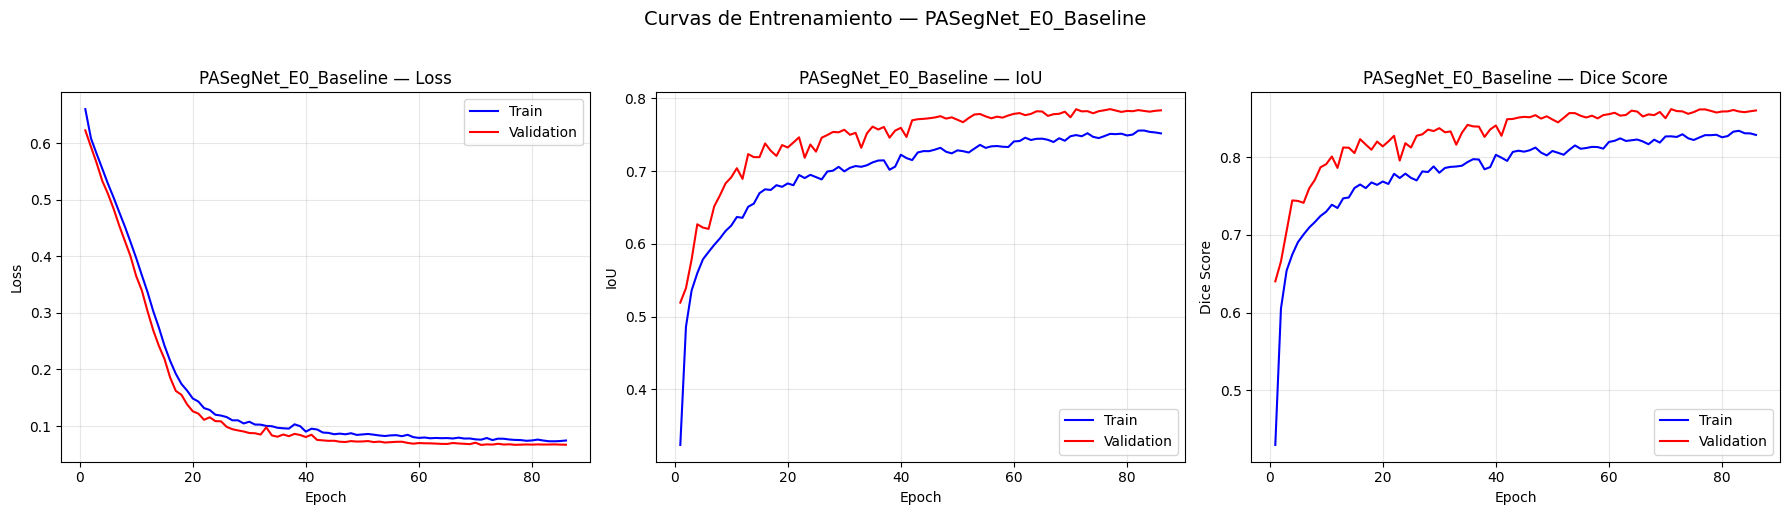


  E0 — Weighted mIoU: 79.83%


In [8]:
# ============================================================
# 7.0 EXPERIMENTO E0 — BASELINE
# ============================================================

E0_NAME = 'PASegNet_E0_Baseline'
e0_ckpt = os.path.join(base_path, 'checkpoints', f'{E0_NAME}_best.pth')
e0_summ = os.path.join(base_path, 'results', f'{E0_NAME.lower()}_summary.json')
e0_hist = os.path.join(base_path, 'results', f'{E0_NAME.lower()}_history.json')
e0_done = all(os.path.exists(p) for p in [e0_ckpt, e0_summ, e0_hist])

if e0_done:
    print(f"  {E0_NAME} ya entrenado. Cargando desde disco...")
    with open(e0_hist) as f: e0_history = json.load(f)
    with open(e0_summ) as f: e0_summary = json.load(f)
    e0_results = pd.read_csv(os.path.join(
        base_path, 'results', f'{E0_NAME.lower()}_test_results.csv'))
    ckpt = torch.load(e0_ckpt, map_location='cpu', weights_only=True)
    print(f"  Val Dice: {ckpt['val_dice']:.4f} (epoch {ckpt['epoch']})")
else:
    print(f"  Iniciando entrenamiento: {E0_NAME}...")
    e0_model = build_pasegnet_e0()
    e0_model, e0_history = train_pasegnet(
        e0_model, E0_NAME, train_loader, val_loader, device,
        use_boundary_loss=False)
    e0_results, e0_summary = save_pasegnet_results(
        E0_NAME, e0_model, e0_history, test_loader, device, base_path)
    del e0_model
    torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

plot_training_curves_pasegnet(e0_history, E0_NAME)
print(f"\n  E0 — Weighted mIoU: {float(e0_summary['weighted_miou'])*100:.2f}%")


### Experimento E1 — +ASPP+

El módulo ASPP+ reemplaza el cuello de botella estándar por un bloque
de convoluciones dilatadas con tasas r={1,6,12,18} y Global Average
Pooling, fusionados mediante Channel Attention. Este experimento evalúa
si capturar el tumor a múltiples escalas simultáneamente mejora la
segmentación de Glioma, que presentó el Dice más bajo (~76%) en los
benchmarks debido a su morfología difusa e irregular.


  Iniciando entrenamiento: PASegNet_E1_ASPPPlus...

  ENTRENAMIENTO: PASegNet_E1_ASPPPlus
  Parámetros totales     :   26,403,217
  Parámetros entrenables :   26,403,217
  Tamaño del modelo      :      100.7 MB
  Epoch   1/100 │ Train Loss:0.7780 IoU:0.2469 Dice:0.3458 │ Val Loss:0.7427 IoU:0.4553 Dice:0.5882 │ LR:1.0e-04 │ 51.4s ★ BEST
  Epoch   2/100 │ Train Loss:0.7296 IoU:0.4438 Dice:0.5726 │ Val Loss:0.7199 IoU:0.5067 Dice:0.6441 │ LR:1.0e-04 │ 52.3s ★ BEST
  Epoch   3/100 │ Train Loss:0.7058 IoU:0.5011 Dice:0.6268 │ Val Loss:0.6995 IoU:0.5142 Dice:0.6538 │ LR:1.0e-04 │ 51.6s ★ BEST
  Epoch   4/100 │ Train Loss:0.6834 IoU:0.5275 Dice:0.6514 │ Val Loss:0.6788 IoU:0.5278 Dice:0.6654 │ LR:1.0e-04 │ 51.2s ★ BEST
  Epoch   5/100 │ Train Loss:0.6618 IoU:0.5482 Dice:0.6690 │ Val Loss:0.6549 IoU:0.5556 Dice:0.6891 │ LR:1.0e-04 │ 51.7s ★ BEST
  Epoch   6/100 │ Train Loss:0.6407 IoU:0.5622 Dice:0.6820 │ Val Loss:0.6365 IoU:0.6237 Dice:0.7442 │ LR:1.0e-04 │ 51.3s ★ BEST
  Epoch   7/100 │ Tra

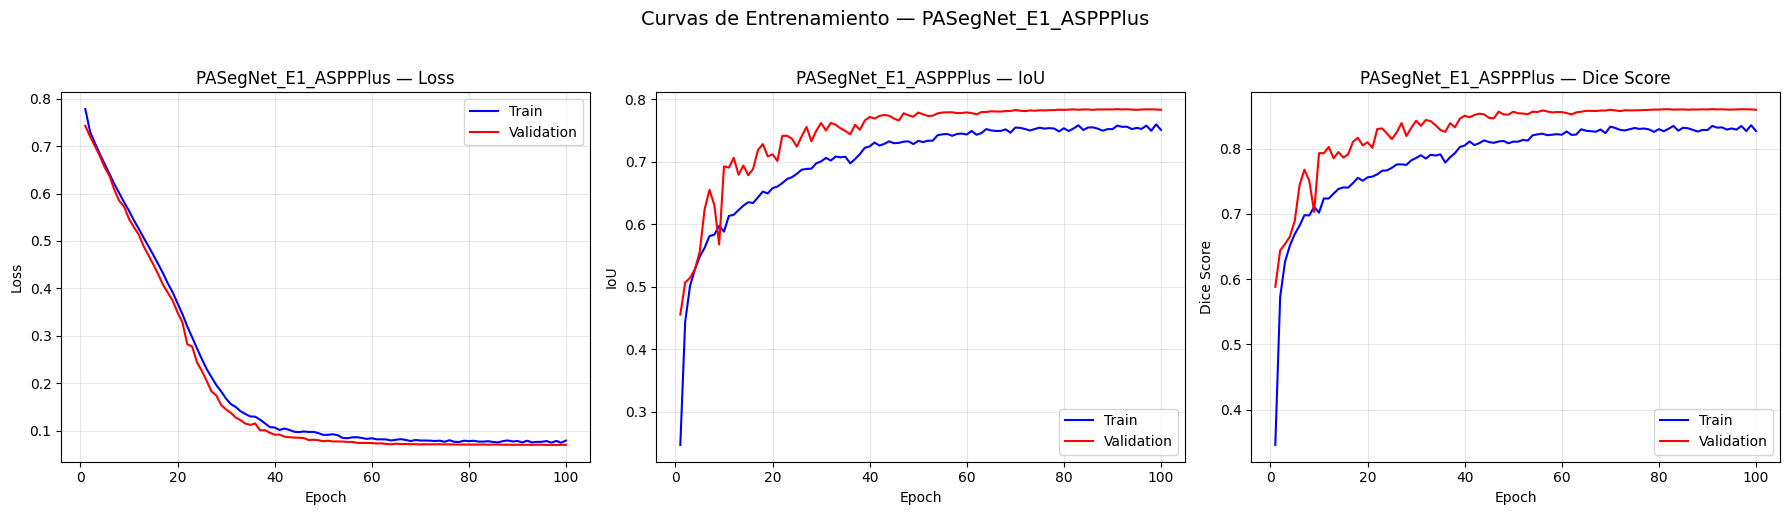


  E1 — Weighted mIoU: 79.49%


In [9]:
# ============================================================
# 7.1 EXPERIMENTO E1 — +ASPP+
# ============================================================

E1_NAME = 'PASegNet_E1_ASPPPlus'
e1_ckpt = os.path.join(base_path, 'checkpoints', f'{E1_NAME}_best.pth')
e1_summ = os.path.join(base_path, 'results', f'{E1_NAME.lower()}_summary.json')
e1_hist = os.path.join(base_path, 'results', f'{E1_NAME.lower()}_history.json')
e1_done = all(os.path.exists(p) for p in [e1_ckpt, e1_summ, e1_hist])

if e1_done:
    print(f"  {E1_NAME} ya entrenado. Cargando desde disco...")
    with open(e1_hist) as f: e1_history = json.load(f)
    with open(e1_summ) as f: e1_summary = json.load(f)
    e1_results = pd.read_csv(os.path.join(
        base_path, 'results', f'{E1_NAME.lower()}_test_results.csv'))
    ckpt = torch.load(e1_ckpt, map_location='cpu', weights_only=True)
    print(f"  Val Dice: {ckpt['val_dice']:.4f} (epoch {ckpt['epoch']})")
else:
    print(f"  Iniciando entrenamiento: {E1_NAME}...")
    e1_model = build_pasegnet_e1()
    e1_model, e1_history = train_pasegnet(
        e1_model, E1_NAME, train_loader, val_loader, device,
        use_boundary_loss=False)
    e1_results, e1_summary = save_pasegnet_results(
        E1_NAME, e1_model, e1_history, test_loader, device, base_path)
    del e1_model
    torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

plot_training_curves_pasegnet(e1_history, E1_NAME)
print(f"\n  E1 — Weighted mIoU: {float(e1_summary['weighted_miou'])*100:.2f}%")


### Experimento E2 — +Attention Gates

Los Attention Gates reemplazan las skip connections directas del decoder
por conexiones atendidas: una señal de gating proveniente del decoder
(enriquecida con información de plano vía FiLM) genera un mapa de
atención α que suprime píxeles de fondo irrelevantes antes de la
concatenación. Con un 98.3% de píxeles de fondo en el dataset, este
mecanismo busca reducir el ruido que las skip connections clásicas
transfieren al decoder, mejorando la precisión en bordes tumorales.


  Iniciando entrenamiento: PASegNet_E2_AttGates...

  ENTRENAMIENTO: PASegNet_E2_AttGates
  Parámetros totales     :   22,786,061
  Parámetros entrenables :   22,786,061
  Tamaño del modelo      :       86.9 MB
  Epoch   1/100 │ Train Loss:0.7399 IoU:0.2246 Dice:0.3215 │ Val Loss:0.6968 IoU:0.3740 Dice:0.5129 │ LR:1.0e-04 │ 67.1s ★ BEST
  Epoch   2/100 │ Train Loss:0.6815 IoU:0.4401 Dice:0.5675 │ Val Loss:0.6653 IoU:0.4045 Dice:0.5474 │ LR:1.0e-04 │ 62.1s ★ BEST
  Epoch   3/100 │ Train Loss:0.6491 IoU:0.5056 Dice:0.6283 │ Val Loss:0.6221 IoU:0.5938 Dice:0.7145 │ LR:1.0e-04 │ 62.8s ★ BEST
  Epoch   4/100 │ Train Loss:0.6188 IoU:0.5402 Dice:0.6609 │ Val Loss:0.5981 IoU:0.5506 Dice:0.6815 │ LR:1.0e-04 │ 63.1s (patience: 1/15)
  Epoch   5/100 │ Train Loss:0.5914 IoU:0.5581 Dice:0.6756 │ Val Loss:0.5668 IoU:0.6528 Dice:0.7641 │ LR:1.0e-04 │ 63.2s ★ BEST
  Epoch   6/100 │ Train Loss:0.5651 IoU:0.5722 Dice:0.6877 │ Val Loss:0.5442 IoU:0.6472 Dice:0.7589 │ LR:1.0e-04 │ 62.5s (patience: 1/15)
 

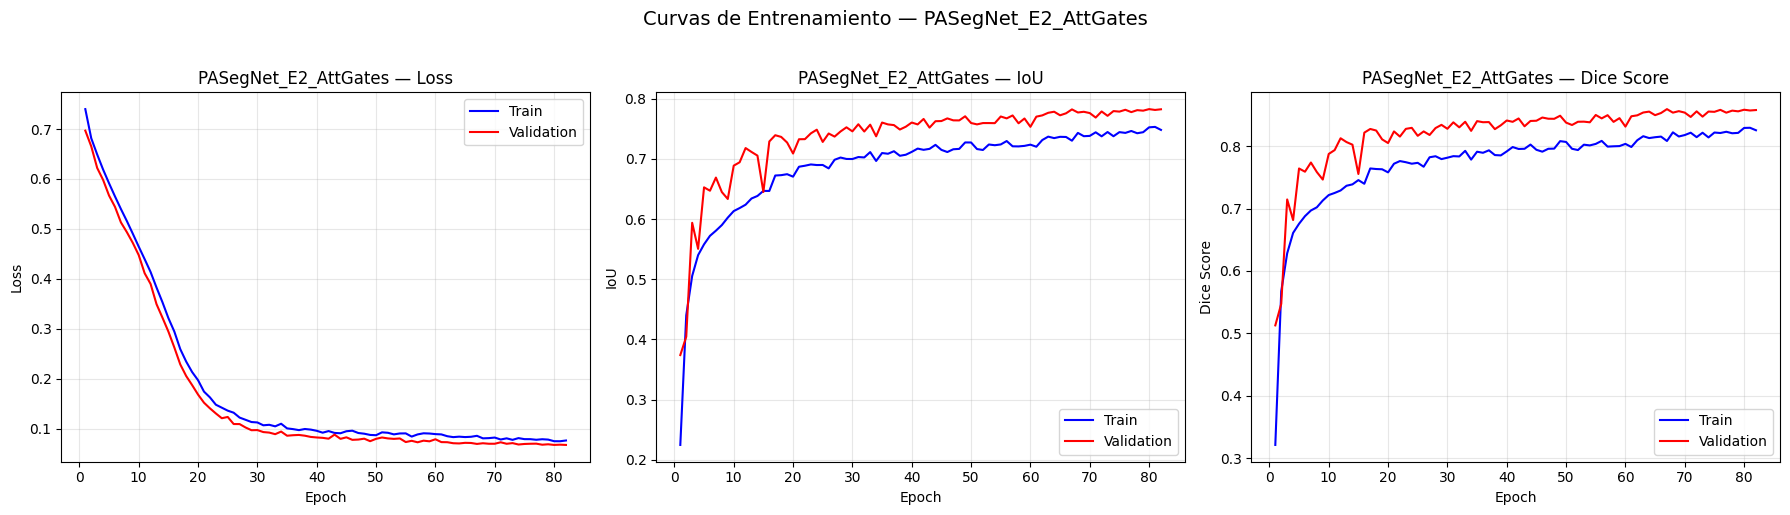


  E2 — Weighted mIoU: 79.64%


In [10]:
# ============================================================
# 7.2 EXPERIMENTO E2 — +ATTENTION GATES
# ============================================================

E2_NAME = 'PASegNet_E2_AttGates'
e2_ckpt = os.path.join(base_path, 'checkpoints', f'{E2_NAME}_best.pth')
e2_summ = os.path.join(base_path, 'results', f'{E2_NAME.lower()}_summary.json')
e2_hist = os.path.join(base_path, 'results', f'{E2_NAME.lower()}_history.json')
e2_done = all(os.path.exists(p) for p in [e2_ckpt, e2_summ, e2_hist])

if e2_done:
    print(f"  {E2_NAME} ya entrenado. Cargando desde disco...")
    with open(e2_hist) as f: e2_history = json.load(f)
    with open(e2_summ) as f: e2_summary = json.load(f)
    e2_results = pd.read_csv(os.path.join(
        base_path, 'results', f'{E2_NAME.lower()}_test_results.csv'))
    ckpt = torch.load(e2_ckpt, map_location='cpu', weights_only=True)
    print(f"  Val Dice: {ckpt['val_dice']:.4f} (epoch {ckpt['epoch']})")
else:
    print(f"  Iniciando entrenamiento: {E2_NAME}...")
    e2_model = build_pasegnet_e2()
    e2_model, e2_history = train_pasegnet(
        e2_model, E2_NAME, train_loader, val_loader, device,
        use_boundary_loss=False)
    e2_results, e2_summary = save_pasegnet_results(
        E2_NAME, e2_model, e2_history, test_loader, device, base_path)
    del e2_model
    torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

plot_training_curves_pasegnet(e2_history, E2_NAME)
print(f"\n  E2 — Weighted mIoU: {float(e2_summary['weighted_miou'])*100:.2f}%")


### Experimento E3 — +FiLM

El módulo FiLM (*Feature-wise Linear Modulation*) condiciona los feature
maps del bottleneck al plano anatómico de cada imagen mediante parámetros
de escala (γ) y sesgo (β) aprendidos por plano:
FiLM(F, p) = γ_p ⊙ F + β_p.

Este experimento evalúa directamente el hallazgo original de este trabajo:
los 5 modelos de la Fase 5 exhiben el patrón Sagittal > Coronal > Axial
con ~3 puntos porcentuales de diferencia (p<0.0001). Si FiLM es efectivo,
se esperan dos resultados: mejora del mIoU global y reducción de la brecha
entre planos anatómicos.


  Iniciando entrenamiento: PASegNet_E3_FiLM...

  ENTRENAMIENTO: PASegNet_E3_FiLM
  Parámetros totales     :   22,561,169
  Parámetros entrenables :   22,561,169
  Tamaño del modelo      :       86.1 MB
  Epoch   1/100 │ Train Loss:0.7103 IoU:0.2775 Dice:0.3792 │ Val Loss:0.6702 IoU:0.4317 Dice:0.5618 │ LR:1.0e-04 │ 65.6s ★ BEST
  Epoch   2/100 │ Train Loss:0.6567 IoU:0.4699 Dice:0.5905 │ Val Loss:0.6437 IoU:0.5202 Dice:0.6546 │ LR:1.0e-04 │ 61.8s ★ BEST
  Epoch   3/100 │ Train Loss:0.6302 IoU:0.5202 Dice:0.6396 │ Val Loss:0.6150 IoU:0.6013 Dice:0.7165 │ LR:1.0e-04 │ 62.0s ★ BEST
  Epoch   4/100 │ Train Loss:0.6065 IoU:0.5467 Dice:0.6628 │ Val Loss:0.5908 IoU:0.6168 Dice:0.7359 │ LR:1.0e-04 │ 60.8s ★ BEST
  Epoch   5/100 │ Train Loss:0.5834 IoU:0.5640 Dice:0.6800 │ Val Loss:0.5681 IoU:0.5936 Dice:0.7200 │ LR:1.0e-04 │ 60.8s (patience: 1/15)
  Epoch   6/100 │ Train Loss:0.5607 IoU:0.5800 Dice:0.6939 │ Val Loss:0.5473 IoU:0.6507 Dice:0.7593 │ LR:1.0e-04 │ 59.3s ★ BEST
  Epoch   7/100 │ T

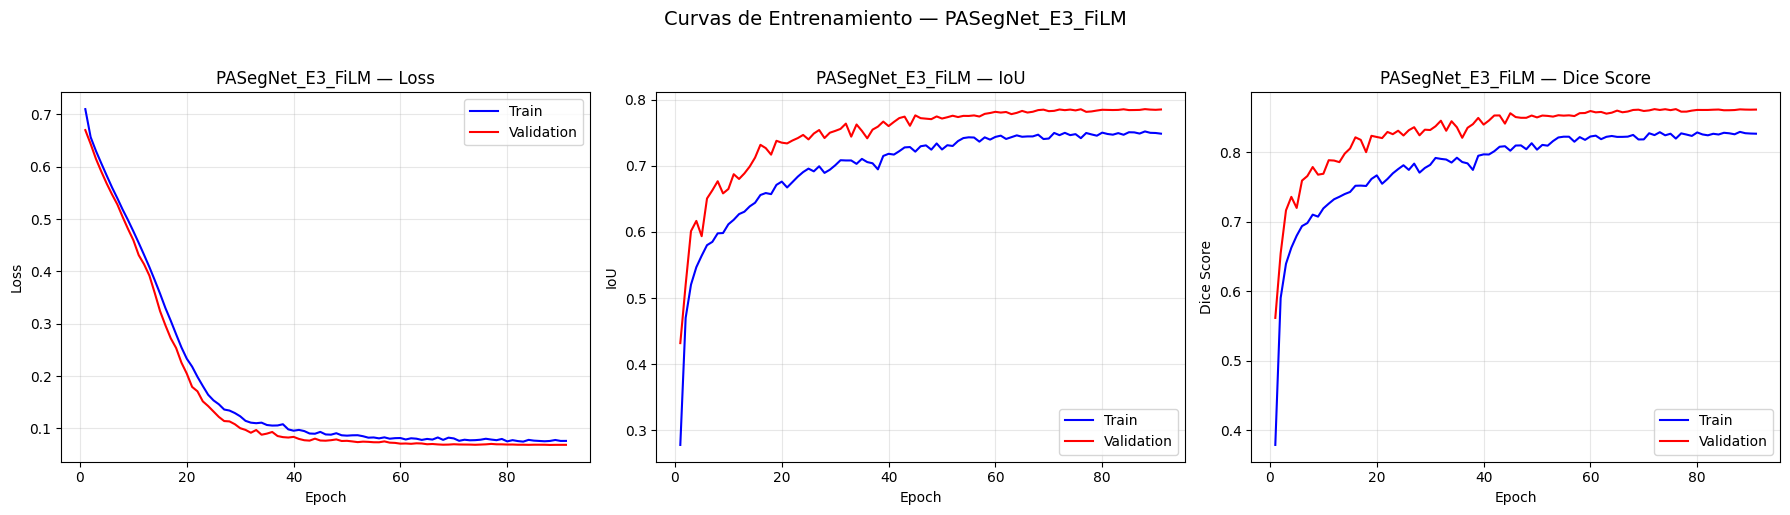


  E3 — Weighted mIoU: 79.78%


In [11]:
# ============================================================
# 7.3 EXPERIMENTO E3 — +FiLM
# ============================================================

E3_NAME = 'PASegNet_E3_FiLM'
e3_ckpt = os.path.join(base_path, 'checkpoints', f'{E3_NAME}_best.pth')
e3_summ = os.path.join(base_path, 'results', f'{E3_NAME.lower()}_summary.json')
e3_hist = os.path.join(base_path, 'results', f'{E3_NAME.lower()}_history.json')
e3_done = all(os.path.exists(p) for p in [e3_ckpt, e3_summ, e3_hist])

if e3_done:
    print(f"  {E3_NAME} ya entrenado. Cargando desde disco...")
    with open(e3_hist) as f: e3_history = json.load(f)
    with open(e3_summ) as f: e3_summary = json.load(f)
    e3_results = pd.read_csv(os.path.join(
        base_path, 'results', f'{E3_NAME.lower()}_test_results.csv'))
    ckpt = torch.load(e3_ckpt, map_location='cpu', weights_only=True)
    print(f"  Val Dice: {ckpt['val_dice']:.4f} (epoch {ckpt['epoch']})")
else:
    print(f"  Iniciando entrenamiento: {E3_NAME}...")
    e3_model = build_pasegnet_e3()
    e3_model, e3_history = train_pasegnet(
        e3_model, E3_NAME, train_loader, val_loader, device,
        use_boundary_loss=False)
    e3_results, e3_summary = save_pasegnet_results(
        E3_NAME, e3_model, e3_history, test_loader, device, base_path)
    del e3_model
    torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

plot_training_curves_pasegnet(e3_history, E3_NAME)
print(f"\n  E3 — Weighted mIoU: {float(e3_summary['weighted_miou'])*100:.2f}%")


### Experimento E4 — +BoundaryLoss

Este experimento evalúa el aporte de la función de pérdida compuesta
PASegNetLoss sobre la misma arquitectura baseline (sin modificaciones
arquitecturales). La función añade un término de borde:

$$\mathcal{L} = 0.5 \cdot \mathcal{L}_{Dice} +
0.3 \cdot \mathcal{L}_{BCE} + 0.2 \cdot \mathcal{L}_{boundary}$$

La región de borde se extrae mediante morfología (dilatación − erosión
de la máscara ground truth). Este experimento aísla la contribución
de la función de pérdida de la contribución arquitectural, permitiendo
determinar si la mejora en bordes tumorales proviene del diseño del
modelo o del término de pérdida.


  Iniciando entrenamiento: PASegNet_E4_BoundaryLoss...

  ENTRENAMIENTO: PASegNet_E4_BoundaryLoss
  Parámetros totales     :   22,558,097
  Parámetros entrenables :   22,558,097
  Tamaño del modelo      :       86.1 MB
  Epoch   1/100 │ Train Loss:0.7190 IoU:0.3420 Dice:0.4456 │ Val Loss:0.6917 IoU:0.5452 Dice:0.6705 │ LR:1.0e-04 │ 65.4s ★ BEST
  Epoch   2/100 │ Train Loss:0.6856 IoU:0.4942 Dice:0.6191 │ Val Loss:0.6688 IoU:0.5662 Dice:0.6908 │ LR:1.0e-04 │ 59.5s ★ BEST
  Epoch   3/100 │ Train Loss:0.6640 IoU:0.5258 Dice:0.6484 │ Val Loss:0.6487 IoU:0.6321 Dice:0.7471 │ LR:1.0e-04 │ 62.2s ★ BEST
  Epoch   4/100 │ Train Loss:0.6417 IoU:0.5385 Dice:0.6586 │ Val Loss:0.6233 IoU:0.5902 Dice:0.7124 │ LR:1.0e-04 │ 61.8s (patience: 1/15)
  Epoch   5/100 │ Train Loss:0.6172 IoU:0.5542 Dice:0.6723 │ Val Loss:0.5977 IoU:0.6503 Dice:0.7566 │ LR:1.0e-04 │ 61.9s ★ BEST
  Epoch   6/100 │ Train Loss:0.5920 IoU:0.5692 Dice:0.6851 │ Val Loss:0.5720 IoU:0.6234 Dice:0.7396 │ LR:1.0e-04 │ 61.4s (patience:

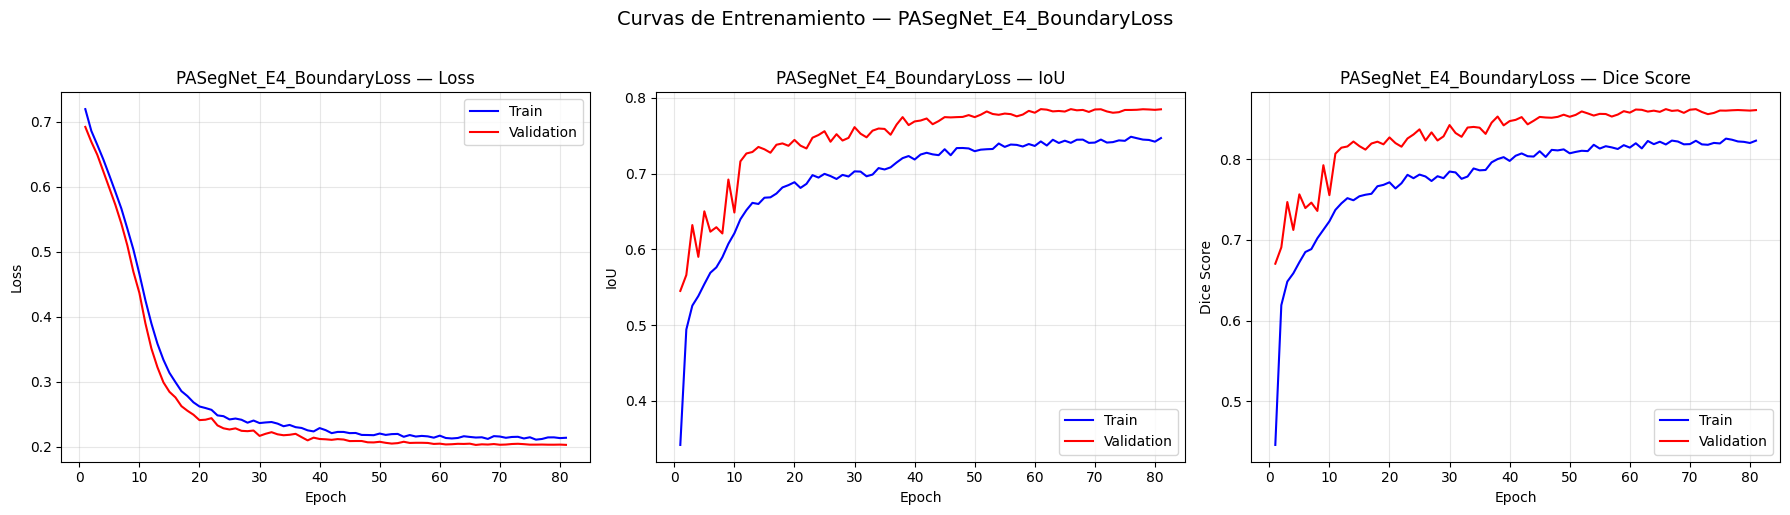


  E4 — Weighted mIoU: 79.47%


In [14]:
# ============================================================
# 7.4 EXPERIMENTO E4 — +BOUNDARY LOSS
# ============================================================

E4_NAME = 'PASegNet_E4_BoundaryLoss'
e4_ckpt = os.path.join(base_path, 'checkpoints', f'{E4_NAME}_best.pth')
e4_summ = os.path.join(base_path, 'results', f'{E4_NAME.lower()}_summary.json')
e4_hist = os.path.join(base_path, 'results', f'{E4_NAME.lower()}_history.json')
e4_done = all(os.path.exists(p) for p in [e4_ckpt, e4_summ, e4_hist])

if e4_done:
    print(f"  {E4_NAME} ya entrenado. Cargando desde disco...")
    with open(e4_hist) as f: e4_history = json.load(f)
    with open(e4_summ) as f: e4_summary = json.load(f)
    e4_results = pd.read_csv(os.path.join(
        base_path, 'results', f'{E4_NAME.lower()}_test_results.csv'))
    ckpt = torch.load(e4_ckpt, map_location='cpu', weights_only=True)
    print(f"  Val Dice: {ckpt['val_dice']:.4f} (epoch {ckpt['epoch']})")
else:
    print(f"  Iniciando entrenamiento: {E4_NAME}...")
    e4_model = build_pasegnet_e4()
    e4_model, e4_history = train_pasegnet(
        e4_model, E4_NAME, train_loader, val_loader, device,
        use_boundary_loss=True)
    e4_results, e4_summary = save_pasegnet_results(
        E4_NAME, e4_model, e4_history, test_loader, device, base_path)
    del e4_model
    torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

plot_training_curves_pasegnet(e4_history, E4_NAME)
print(f"\n  E4 — Weighted mIoU: {float(e4_summary['weighted_miou'])*100:.2f}%")


### Experimento E5 — PASegNet Completo

Integración de todos los componentes de PASegNet: ASPP+ en el bottleneck,
Attention Gates con FiLM en las skip connections, y PASegNetLoss con
término de borde. Los experimentos E1–E4 demostraron la contribución
individual de cada módulo; este experimento evalúa si los componentes
operan de forma sinérgica o si existe interferencia entre ellos.

**Meta cuantitativa:**
- Weighted mIoU > **80.6%** — superar SaberNet (Fateh et al., 2026)
- Global Dice > **0.8674** — superar UNet++ (mejor benchmark, Fase 5)


In [ ]:
# ============================================================
# 7.5 EXPERIMENTO E5 — PASegNet COMPLETO
# ============================================================

E5_NAME = 'PASegNet_E5_Full'
e5_ckpt = os.path.join(base_path, 'checkpoints', f'{E5_NAME}_best.pth')
e5_summ = os.path.join(base_path, 'results', f'{E5_NAME.lower()}_summary.json')
e5_hist = os.path.join(base_path, 'results', f'{E5_NAME.lower()}_history.json')
e5_done = all(os.path.exists(p) for p in [e5_ckpt, e5_summ, e5_hist])

if e5_done:
    print(f"  {E5_NAME} ya entrenado. Cargando desde disco...")
    with open(e5_hist) as f: e5_history = json.load(f)
    with open(e5_summ) as f: e5_summary = json.load(f)
    e5_results = pd.read_csv(os.path.join(
        base_path, 'results', f'{E5_NAME.lower()}_test_results.csv'))
    ckpt = torch.load(e5_ckpt, map_location='cpu', weights_only=True)
    print(f"  Val Dice: {ckpt['val_dice']:.4f} (epoch {ckpt['epoch']})")
else:
    print(f"  Iniciando entrenamiento: {E5_NAME}...")
    e5_model = build_pasegnet()
    e5_model, e5_history = train_pasegnet(
        e5_model, E5_NAME, train_loader, val_loader, device,
        use_boundary_loss=True)
    e5_results, e5_summary = save_pasegnet_results(
        E5_NAME, e5_model, e5_history, test_loader, device, base_path)
    del e5_model
    torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

plot_training_curves_pasegnet(e5_history, E5_NAME)
print(f"\n  E5 — Weighted mIoU: {float(e5_summary['weighted_miou'])*100:.2f}%")


## Sección 8 — Tabla Comparativa Final

**Objetivo:** Posicionar PASegNet respecto a la totalidad de métodos
publicados sobre segmentación en BRISC 2025, incluyendo los resultados
del paper original del dataset, el único trabajo externo de segmentación
(LoGSAM, Bhuiyan et al., 2026), y los benchmarks de la Fase 5 de este trabajo.

Esta tabla constituye el elemento central de la sección de resultados
del paper y la evidencia cuantitativa del aporte de PASegNet al estado
del arte.


In [ ]:
# ============================================================
# 8. TABLA COMPARATIVA FINAL
# ============================================================

# ─── Resultados paper original BRISC ───
brisc_original = [
    {'model':'UNet (BRISC)',       'glioma':69.7,'meningioma':77.1,'pituitary':79.3,'w_miou':75.7,'source':'Fateh et al.'},
    {'model':'UNet++ (BRISC)',     'glioma':71.7,'meningioma':74.2,'pituitary':79.7,'w_miou':75.3,'source':'Fateh et al.'},
    {'model':'MANet (BRISC)',      'glioma':72.4,'meningioma':77.5,'pituitary':78.0,'w_miou':76.2,'source':'Fateh et al.'},
    {'model':'DeepLabV3+ (BRISC)','glioma':72.0,'meningioma':77.5,'pituitary':78.7,'w_miou':76.3,'source':'Fateh et al.'},
    {'model':'EINet (BRISC)',      'glioma':73.6,'meningioma':78.4,'pituitary':80.3,'w_miou':77.7,'source':'Fateh et al.'},
    {'model':'DAD (BRISC)',        'glioma':75.2,'meningioma':80.4,'pituitary':82.3,'w_miou':79.5,'source':'Fateh et al.'},
    {'model':'BASNet (BRISC)',     'glioma':74.0,'meningioma':77.5,'pituitary':81.7,'w_miou':77.9,'source':'Fateh et al.'},
    {'model':'ABANet (BRISC)',     'glioma':72.4,'meningioma':80.4,'pituitary':84.7,'w_miou':79.5,'source':'Fateh et al.'},
    {'model':'SaberNet (BRISC) ★','glioma':74.0,'meningioma':82.4,'pituitary':84.3,'w_miou':80.6,'source':'Fateh et al.'},
    {'model':'LoGSAM',             'glioma':  0.,'meningioma':  0.,'pituitary':  0.,'w_miou':80.3,'source':'Bhuiyan et al.'},
]

# ─── Nuestros benchmarks (Fase 5) ───
BENCHMARK_NAMES = {
    'UNet':          'U-Net (Ours)',
    'AttentionUNet': 'Attention U-Net (Ours)',
    'TransUNet':     'TransUNet (Ours)',
    'UNetPlusPlus':  'UNet++ (Ours)',
    'DeepLabV3Plus': 'DeepLabV3+ (Ours)',
}

bench_rows = []
for bname, display in BENCHMARK_NAMES.items():
    safe  = bname.lower()
    spath = os.path.join(base_path, 'results', f'{safe}_summary.json')
    if os.path.exists(spath):
        with open(spath) as f: s = json.load(f)
        t = s['tumor_iou']
        w = s['weighted_miou']
        sc = 100 if w < 1 else 1
        bench_rows.append({
            'model': display,
            'glioma':     t.get('Glioma',0)*sc,
            'meningioma': t.get('Meningioma',0)*sc,
            'pituitary':  t.get('Pituitary',0)*sc,
            'w_miou':     w*sc,
            'source':     'Ours (Fase 5)',
        })

# ─── Ablation study ───
ablation_experiments = [
    (e0_summary, 'PASegNet E0 — Baseline'),
    (e1_summary, 'PASegNet E1 — +ASPP+'),
    (e2_summary, 'PASegNet E2 — +AttGates'),
    (e3_summary, 'PASegNet E3 — +FiLM'),
    (e4_summary, 'PASegNet E4 — +BoundaryLoss'),
    (e5_summary, 'PASegNet E5 — Full ★'),
]

ablation_rows = []
for summ, display in ablation_experiments:
    t  = summ['tumor_iou']
    w  = summ['weighted_miou']
    sc = 100 if w < 1 else 1
    ablation_rows.append({
        'model':      display,
        'glioma':     t.get('Glioma',0)*sc,
        'meningioma': t.get('Meningioma',0)*sc,
        'pituitary':  t.get('Pituitary',0)*sc,
        'w_miou':     w*sc,
        'source':     'Ours (Propuesto)',
    })

# ─── Tabla unificada ───
all_rows = brisc_original + bench_rows + ablation_rows
df_final = (pd.DataFrame(all_rows)
              .sort_values('w_miou', ascending=False)
              .reset_index(drop=True))
df_final.to_csv(os.path.join(base_path, 'final_comparison.csv'), index=False)

print("\n" + "="*95)
print("  TABLA COMPARATIVA FINAL — SEGMENTACIÓN EN BRISC 2025")
print("="*95)
print(f"\n{'Modelo':<35} {'Glioma':>8} {'Mening.':>8} "
      f"{'Pituit.':>8} {'W-mIoU':>8} {'Fuente':>18}")
print("─"*95)
for _, row in df_final.iterrows():
    g = f"{row['glioma']:.1f}%"   if row['glioma']      > 0 else "    —   "
    m = f"{row['meningioma']:.1f}%" if row['meningioma'] > 0 else "    —   "
    p = f"{row['pituitary']:.1f}%"  if row['pituitary']  > 0 else "    —   "
    print(f"  {row['model']:<33} {g:>8} {m:>8} {p:>8} "
          f"{row['w_miou']:>7.1f}% {row['source']:>18}")
print("─"*95)

# ─── Tabla ablation study ───
print("\n\n" + "="*75)
print("  ABLATION STUDY — Contribución Individual de cada Módulo")
print("="*75)
print(f"\n{'Experimento':<35} {'Glioma':>8} {'Mening.':>8} "
      f"{'Pituit.':>8} {'W-mIoU':>8}")
print("─"*65)
for row in ablation_rows:
    print(f"  {row['model']:<33} "
          f"{row['glioma']:>7.1f}% "
          f"{row['meningioma']:>7.1f}% "
          f"{row['pituitary']:>7.1f}% "
          f"{row['w_miou']:>7.1f}%")
print("─"*65)

# ─── Tabla por plano anatómico ───
print("\n\n" + "="*65)
print("  mIoU POR PLANO ANATÓMICO — Ablation Study")
print("="*65)
print(f"\n{'Experimento':<33} {'Axial':>8} {'Coronal':>8} {'Sagittal':>8}")
print("─"*60)
for summ, display in ablation_experiments:
    p  = summ['plane_iou']
    sc = 100 if summ['weighted_miou'] < 1 else 1
    print(f"  {display:<31} "
          f"{p.get('Axial',0)*sc:>7.2f}% "
          f"{p.get('Coronal',0)*sc:>7.2f}% "
          f"{p.get('Sagittal',0)*sc:>7.2f}%")
print("─"*60)


## Sección 9 — Visualización de Mapas de Atención

**Objetivo:** Visualizar los mapas de atención generados por los
`PlaneAwareAttentionGate` de PASegNet para interpretar qué regiones
de la imagen el modelo considera más relevantes en la segmentación.

Los mapas de atención cumplen dos funciones en el contexto del paper:

1. **Interpretabilidad clínica:** Permiten verificar que el modelo
   concentra su atención en la región tumoral y no en artefactos o
   ruido de fondo, un requisito creciente en publicaciones de imagen médica.

2. **Validación cualitativa del módulo FiLM:** Si la adaptación por plano
   es efectiva, los mapas deberían exhibir patrones diferenciados entre
   imágenes axiales, coronales y sagitales, reflejando la especialización
   aprendida por cada plano.

Se visualiza el mapa del Gate 4 (nivel más profundo del decoder),
que captura contexto semántico de alto nivel, superpuesto sobre
la imagen MRI original.


In [ ]:
# ============================================================
# 9. VISUALIZACIÓN DE MAPAS DE ATENCIÓN — PASegNet E5
# ============================================================

@torch.no_grad()
def visualize_attention_maps(model_path, loader, device, n_samples=3):
    model = build_pasegnet().to(device)
    ckpt  = torch.load(model_path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    imgs, gts, preds, attns, metas_list = [], [], [], [], []

    for images, masks, meta in loader:
        images    = images.to(device)
        masks     = masks.to(device)
        plane_idx = get_plane_idx(meta, device)

        with autocast(device_type='cuda'):
            outputs = model(images, plane_idx)

        preds_bin = (torch.sigmoid(outputs) > 0.5).float().cpu()
        a4 = model.attention_maps['a4'].cpu()

        for i in range(len(images)):
            imgs.append(images[i].cpu())
            gts.append(masks[i].cpu())
            preds.append(preds_bin[i])
            attns.append(a4[i])
            metas_list.append({k: v[i] for k, v in meta.items()})
            if len(imgs) >= n_samples:
                break
        if len(imgs) >= n_samples:
            break

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 4))
    cols = ['Imagen MRI', 'Ground Truth',
            'Predicción PASegNet', 'Mapa de Atención (Gate 4)']

    for i in range(n_samples):
        img_np  = imgs[i][0].numpy()
        gt_np   = gts[i][0].numpy()
        pred_np = preds[i][0].numpy()
        attn_up = F.interpolate(
            attns[i].unsqueeze(0), size=(256,256),
            mode='bilinear', align_corners=False
        ).squeeze().numpy()

        inter = (pred_np * gt_np).sum()
        union = pred_np.sum() + gt_np.sum() - inter
        iou   = inter / (union + 1e-6)

        axes[i,0].imshow(img_np, cmap='gray')
        axes[i,0].set_title(
            f"{metas_list[i]['tumor_label']} / "
            f"{metas_list[i]['plane_label']}", fontsize=9)
        axes[i,0].axis('off')

        axes[i,1].imshow(gt_np, cmap='gray')
        axes[i,1].axis('off')

        axes[i,2].imshow(pred_np, cmap='gray')
        axes[i,2].set_title(f'IoU: {iou*100:.1f}%', fontsize=9)
        axes[i,2].axis('off')

        axes[i,3].imshow(img_np, cmap='gray', alpha=0.5)
        axes[i,3].imshow(attn_up, cmap='hot', alpha=0.7)
        axes[i,3].axis('off')

    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=10, fontweight='bold')

    plt.suptitle('PASegNet — Mapas de Atención por Plano Anatómico',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('pasegnet_attention_maps.png', dpi=150, bbox_inches='tight')
    plt.show()

    del model
    torch.cuda.empty_cache()


e5_ckpt_path = os.path.join(base_path, 'checkpoints', f'{E5_NAME}_best.pth')
if os.path.exists(e5_ckpt_path):
    visualize_attention_maps(e5_ckpt_path, test_loader, device, n_samples=3)
else:
    print("  Checkpoint de E5 no encontrado — entrenar primero.")
